# Acceso a APIs y Preprocesamiento

In [1]:
# Importar librerías
import pandas as pd
import requests
import openpyxl
from io import BytesIO, StringIO
import numpy as np
import folium
import json
import seaborn as sns
import matplotlib.pyplot as plt
import webbrowser



In [2]:
# URL 1: Procedencia y destino de los turistas residentes que visitan una CCAA distinta a la suya
url1 = "https://dataestur.azure-api.net/API-SEGITTUR-v1/TURISMO_INTERNO_PROV_CCAA_DL"
params1 = {
    "desde (año)": 2023,
    "desde (mes)": 1,
    "hasta (año)": 2024,
    "hasta (mes)": 12,
    "CCAA origen": "Todos",
    "Provincia origen": "Todos",
    "CCAA destino": "Todos",
    "Provincia destino": "Todos"
}

response1 = requests.get(url1, params=params1)
if response1.status_code == 200:
    content1 = response1.content.decode("latin1")
    df1 = pd.read_csv(StringIO(content1), sep=";", decimal=",")
    print("df1 loaded:")
    print(df1.head())
else:
    print(f"Failed to download df1: {response1.status_code}")

df1 loaded:
    AÑO  MES CCAA_ORIGEN PROVINCIA_ORIGEN CCAA_DESTINO PROVINCIA_DESTINO  \
0  2023    1   Andalucía          Almería    Andalucía             Cádiz   
1  2023    1   Andalucía          Almería    Andalucía           Córdoba   
2  2023    1   Andalucía          Almería    Andalucía           Granada   
3  2023    1   Andalucía          Almería    Andalucía            Huelva   
4  2023    1   Andalucía          Almería    Andalucía              Jaén   

   TURISTAS  PERNOCTACIONES  ESTANCIA_MEDIA  
0    4205.0         22086.0             5.3  
1    3548.0         18085.0             5.1  
2   44129.0        158519.0             3.6  
3    1660.0          8143.0             4.9  
4    9658.0         52765.0             5.5  


In [3]:
#Cambiar el nombre de columnas en df1
df1 = df1.rename(columns={"TURISTAS": "TURISTAS_INTERNO",
                        "PERNOCTACIONES": "PERNOCTACIONES_INTERNO",
                         "ESTANCIA_MEDIA": "ESTANCIA_MEDIA_INTERNO"})

In [4]:
# URL 2: Procedencia de los turistas extranjeros que viajan a España por CCAA
url2 = "https://dataestur.azure-api.net/API-SEGITTUR-v1/TURISMO_RECEPTOR_CCAA_PAIS_DL"
params2 = {
    "desde (año)": 2023,
    "desde (mes)": 1,
    "hasta (año)": 2024,
    "hasta (mes)": 12,
    "CCAA": "Todos"
}

response2 = requests.get(url2, params=params2)
if response2.status_code == 200:
    content2 = response2.content.decode("latin1")
    df2 = pd.read_csv(StringIO(content2), sep=";", decimal=",")
    print("df2 loaded:")
    print(df2.head())
else:
    print(f"Failed to download df2: {response2.status_code}")


df2 loaded:
    AÑO  MES CCAA_DESTINO CONTINENTE_ORIGEN PAIS_ORIGEN  TURISTAS  \
0  2023    1    Andalucía           América   Argentina    2792.0   
1  2023    1    Andalucía           América     Bolivia      48.0   
2  2023    1    Andalucía           América      Brasil    2599.0   
3  2023    1    Andalucía           América      Canadá    6206.0   
4  2023    1    Andalucía           América       Chile     608.0   

   PERNOCTACIONES  ESTANCIA_MEDIA  
0         29014.0            10.4  
1           487.0            10.1  
2         18613.0             7.2  
3         41535.0             6.7  
4          4644.0             7.6  


In [5]:
# URL 3: Estadística de Ocupación Hotelera por CCAA
url3 = "https://dataestur.azure-api.net/API-SEGITTUR-v1/EOH_CCAA_DL"
params3 = {
    "desde (año)": 2023,
    "desde (mes)": 1,
    "hasta (año)": 2024,
    "hasta (mes)": 12,
    "Lugar de residencia": "Todos",
    "CCAA": "Todos"
}

response3 = requests.get(url3, params=params3)
if response3.status_code == 200:
    excel_file = BytesIO(response3.content)
    df3 = pd.read_excel(excel_file, engine='openpyxl')
    print("df3 loaded:")
    print(df3.head())
else:
    print(f"Failed to download df3: {response3.status_code}")

# Renombrar columnas
df3 = df3.rename(columns={"PERNOCTACIONES": "PERNOCTACIONES_HOTEL",
                          "ESTANCIA_MEDIA": "ESTANCIA_MEDIA_HOTEL"})

df3 loaded:
    AÑO  MES       CCAA             LUGAR_RESIDENCIA  VIAJEROS  \
0  2023    1  Andalucía         Residentes en España    571285   
1  2023    1  Andalucía  Residentes en el Extranjero    383406   
2  2023    1  Andalucía                        Total    954691   
3  2023    1     Aragón         Residentes en España    143876   
4  2023    1     Aragón  Residentes en el Extranjero     25171   

   PERNOCTACIONES  ESTANCIA_MEDIA  ESTABLECIMIENTOS_ESTIMADOS  \
0         1052987            1.84                         NaN   
1         1040807            2.71                         NaN   
2         2093794            2.19                      2066.0   
3          298673            2.08                         NaN   
4           52713            2.09                         NaN   

   HABITACIONES_ESTIMADAS  PLAZAS_ESTIMADAS  GRADO_OCUPA_PLAZAS  \
0                     NaN               NaN                 NaN   
1                     NaN               NaN                 NaN   

In [6]:
# Filtrar filas donde LUGAR_RESIDENCIA contiene "Total" (mayúsculas o minúsculas)
df3_total = df3[df3["LUGAR_RESIDENCIA"].str.contains("Total", case=False, na=False)]

# Buscar filas con NaN en ese subconjunto
nan_total_rows = df3_total[df3_total.isna().any(axis=1)]

print(nan_total_rows)

Empty DataFrame
Columns: [AÑO, MES, CCAA, LUGAR_RESIDENCIA, VIAJEROS, PERNOCTACIONES_HOTEL, ESTANCIA_MEDIA_HOTEL, ESTABLECIMIENTOS_ESTIMADOS, HABITACIONES_ESTIMADAS, PLAZAS_ESTIMADAS, GRADO_OCUPA_PLAZAS, GRADO_OCUPA_PLAZAS_FIN_SEMANA, GRADO_OCUPA_POR_HABITACIONES, PERSONAL_EMPLEADO]
Index: []


In [7]:
#Eliminar filas donde LUGAR_RESIDENCIA es distinto a "Total"
df3 = df3.drop(df3[df3['LUGAR_RESIDENCIA'].isin(['Residentes en España', 'Residentes en el Extranjero'])].index)
df3 = df3.rename(columns={"CCAA": "CCAA_DESTINO"})
print(df3.head())

     AÑO  MES          CCAA_DESTINO LUGAR_RESIDENCIA  VIAJEROS  \
2   2023    1             Andalucía            Total    954691   
5   2023    1                Aragón            Total    169047   
8   2023    1              Canarias            Total    805529   
11  2023    1             Cantabria            Total     39213   
14  2023    1  Castilla - La Mancha            Total    124348   

    PERNOCTACIONES_HOTEL  ESTANCIA_MEDIA_HOTEL  ESTABLECIMIENTOS_ESTIMADOS  \
2                2093794                  2.19                      2066.0   
5                 351386                  2.08                       599.0   
8                5705808                  7.08                       574.0   
11                 68106                  1.74                       205.0   
14                215464                  1.73                       648.0   

    HABITACIONES_ESTIMADAS  PLAZAS_ESTIMADAS  GRADO_OCUPA_PLAZAS  \
2                  83599.0          176415.0               38.04  

In [8]:
# Sum TURISTAS_INTERNO y PERNOCTACIONES_INTERNO by AÑO, MES, y CCAA_DESTINO
df1_total_by_destino = df1.groupby(["AÑO", "MES", "CCAA_DESTINO"]).agg({
    "TURISTAS_INTERNO": "sum",
    "PERNOCTACIONES_INTERNO": "sum"
}).reset_index()

# Recalcular ESTANCIA_MEDIA
df1_total_by_destino["ESTANCIA_MEDIA_INTERNO"] = (
    df1_total_by_destino["PERNOCTACIONES_INTERNO"] / df1_total_by_destino["TURISTAS_INTERNO"]
).round(1)

print(df1_total_by_destino.head())

    AÑO  MES          CCAA_DESTINO  TURISTAS_INTERNO  PERNOCTACIONES_INTERNO  \
0  2023    1             Andalucía         4512199.0              21150031.0   
1  2023    1                Aragón         1130597.0               4596125.0   
2  2023    1              Canarias          526706.0               3647214.0   
3  2023    1             Cantabria          355686.0               1611258.0   
4  2023    1  Castilla - La Mancha         2042724.0               7604971.0   

   ESTANCIA_MEDIA_INTERNO  
0                     4.7  
1                     4.1  
2                     6.9  
3                     4.5  
4                     3.7  


In [9]:
# Sum TURISTAS y PERNOCTACIONES by AÑO, MES y CCAA_DESTINO
df2_total_by_destino = df2.groupby(["AÑO", "MES", "CCAA_DESTINO"]).agg({
    "TURISTAS": "sum",
    "PERNOCTACIONES": "sum"
}).reset_index()

# Recalcular ESTANCIA_MEDIA 
df2_total_by_destino["ESTANCIA_MEDIA"] = (
    df2_total_by_destino["PERNOCTACIONES"] / df2_total_by_destino["TURISTAS"]
).round(1)

#Cambiar el nombre de columnas
df2_total_by_destino = df2_total_by_destino.rename(columns={"TURISTAS": "TURISTAS_RECEPTOR",
                                                           "PERNOCTACIONES": "PERNOCTACIONES_RECEPTOR",
                                                           "ESTANCIA_MEDIA": "ESTANCIA_MEDIA_RECEPTOR"})

print(df2_total_by_destino.head())

    AÑO  MES          CCAA_DESTINO  TURISTAS_RECEPTOR  \
0  2023    1             Andalucía          1986905.0   
1  2023    1                Aragón           174218.0   
2  2023    1              Canarias          3492635.0   
3  2023    1             Cantabria            60852.0   
4  2023    1  Castilla - La Mancha           205965.0   

   PERNOCTACIONES_RECEPTOR  ESTANCIA_MEDIA_RECEPTOR  
0               16395207.0                      8.3  
1                1391987.0                      8.0  
2               28372063.0                      8.1  
3                 507129.0                      8.3  
4                1820624.0                      8.8  


In [10]:
print("Shape of df1_total_by_destino:", df1_total_by_destino.shape)
print("Shape of df2_total_by_destino:", df2_total_by_destino.shape)
print("Shape of df3:", df3.shape)

Shape of df1_total_by_destino: (456, 6)
Shape of df2_total_by_destino: (480, 6)
Shape of df3: (480, 14)


In [11]:
# Select only the key columns for comparison
keys_df1 = df1_total_by_destino[["AÑO", "MES", "CCAA_DESTINO"]].drop_duplicates()
keys_df2 = df2_total_by_destino[["AÑO", "MES", "CCAA_DESTINO"]].drop_duplicates()

# Find rows in df2 keys that are NOT in df1 keys
missing_in_df1 = keys_df2.merge(keys_df1, on=["AÑO", "MES", "CCAA_DESTINO"], how="left", indicator=True)
missing_in_df1 = missing_in_df1[missing_in_df1["_merge"] == "left_only"]

print(f"Rows in df2_total_by_destino but NOT in df1_total_by_destino: {len(missing_in_df1)}")
print(missing_in_df1)



Rows in df2_total_by_destino but NOT in df1_total_by_destino: 24
      AÑO  MES    CCAA_DESTINO     _merge
19   2023    1  Total Nacional  left_only
39   2023    2  Total Nacional  left_only
59   2023    3  Total Nacional  left_only
79   2023    4  Total Nacional  left_only
99   2023    5  Total Nacional  left_only
119  2023    6  Total Nacional  left_only
139  2023    7  Total Nacional  left_only
159  2023    8  Total Nacional  left_only
179  2023    9  Total Nacional  left_only
199  2023   10  Total Nacional  left_only
219  2023   11  Total Nacional  left_only
239  2023   12  Total Nacional  left_only
259  2024    1  Total Nacional  left_only
279  2024    2  Total Nacional  left_only
299  2024    3  Total Nacional  left_only
319  2024    4  Total Nacional  left_only
339  2024    5  Total Nacional  left_only
359  2024    6  Total Nacional  left_only
379  2024    7  Total Nacional  left_only
399  2024    8  Total Nacional  left_only
419  2024    9  Total Nacional  left_only
439  2024  

In [12]:
# Calculamos los totales nacionales mensuales
total_nacional = df1.groupby(["AÑO", "MES"]).agg(
    {"TURISTAS_INTERNO": "sum", "PERNOCTACIONES_INTERNO": "sum"}
).reset_index()

# Calculamos la estancia media ponderada
total_nacional["ESTANCIA_MEDIA_INTERNO"] = df1.groupby(["AÑO", "MES"]).apply(
    lambda g: (g["ESTANCIA_MEDIA_INTERNO"] * g["TURISTAS_INTERNO"]).sum() / g["TURISTAS_INTERNO"].sum()
).values

# Añadimos la columna CCAA_DESTINO con "Total Nacional"
total_nacional["CCAA_DESTINO"] = "Total Nacional"

# Reordenamos las columnas para que coincidan con df1_total_by_destino
total_nacional = total_nacional[["AÑO", "MES", "CCAA_DESTINO", "TURISTAS_INTERNO", "PERNOCTACIONES_INTERNO", "ESTANCIA_MEDIA_INTERNO"]]

# Añadimos una columna auxiliar para ordenar: 0 para normales, 1 para Total Nacional
df1_total_by_destino["order_aux"] = 0
total_nacional["order_aux"] = 1

# Concatenamos y ordenamos
df1_total_by_destino = pd.concat([df1_total_by_destino, total_nacional], ignore_index=True)
df1_total_by_destino = df1_total_by_destino.sort_values(by=["AÑO", "MES", "order_aux"]).reset_index(drop=True)

# Eliminamos la columna auxiliar
df1_total_by_destino = df1_total_by_destino.drop(columns="order_aux")

print(df1_total_by_destino.head())


    AÑO  MES          CCAA_DESTINO  TURISTAS_INTERNO  PERNOCTACIONES_INTERNO  \
0  2023    1             Andalucía         4512199.0              21150031.0   
1  2023    1                Aragón         1130597.0               4596125.0   
2  2023    1              Canarias          526706.0               3647214.0   
3  2023    1             Cantabria          355686.0               1611258.0   
4  2023    1  Castilla - La Mancha         2042724.0               7604971.0   

   ESTANCIA_MEDIA_INTERNO  
0                     4.7  
1                     4.1  
2                     6.9  
3                     4.5  
4                     3.7  


C:\Users\santi\AppData\Local\Temp\ipykernel_7012\2916114771.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_nacional["ESTANCIA_MEDIA_INTERNO"] = df1.groupby(["AÑO", "MES"]).apply(


In [13]:
# Unir todos los df en uno solo que sea el principal
df = pd.concat([df1_total_by_destino.reset_index(drop=True),
                df2_total_by_destino.reset_index(drop=True),
                df3.reset_index(drop=True)], axis=1)
# Identificar columnas no duplicadas
df = df.loc[:, ~df.columns.duplicated(keep='first')]
# Drop las columnas de LUGAR_RESIDENCIA y PERSONAL_EMPLEADO
df = df.drop(columns=["PERSONAL_EMPLEADO", "LUGAR_RESIDENCIA"])

print(df.head())

    AÑO  MES          CCAA_DESTINO  TURISTAS_INTERNO  PERNOCTACIONES_INTERNO  \
0  2023    1             Andalucía         4512199.0              21150031.0   
1  2023    1                Aragón         1130597.0               4596125.0   
2  2023    1              Canarias          526706.0               3647214.0   
3  2023    1             Cantabria          355686.0               1611258.0   
4  2023    1  Castilla - La Mancha         2042724.0               7604971.0   

   ESTANCIA_MEDIA_INTERNO  TURISTAS_RECEPTOR  PERNOCTACIONES_RECEPTOR  \
0                     4.7          1986905.0               16395207.0   
1                     4.1           174218.0                1391987.0   
2                     6.9          3492635.0               28372063.0   
3                     4.5            60852.0                 507129.0   
4                     3.7           205965.0                1820624.0   

   ESTANCIA_MEDIA_RECEPTOR  VIAJEROS  PERNOCTACIONES_HOTEL  \
0                 

In [14]:
# Crear columnas con la suma de turistas y pernoctaciones
df["TURISTAS_NACIONAL"] = df["TURISTAS_INTERNO"] + df["TURISTAS_RECEPTOR"]
df["PERNOCTACIONES_NACIONAL"] = df["PERNOCTACIONES_INTERNO"] + df["PERNOCTACIONES_RECEPTOR"]

# Calcular estancia media nacional como la división de pernoctaciones entre turistas
df["ESTANCIA_MEDIA_NACIONAL"] = df["PERNOCTACIONES_NACIONAL"] / df["TURISTAS_NACIONAL"].round(1)

# Crear columna de FECHA para poder utilizar variables temporales en el análisis
df['FECHA'] = pd.to_datetime(df['AÑO'].astype(str) + '-' + df['MES'].astype(str).str.zfill(2))

df.head()


,AÑO,MES,CCAA_DESTINO,TURISTAS_INTERNO,PERNOCTACIONES_INTERNO,ESTANCIA_MEDIA_INTERNO,TURISTAS_RECEPTOR,PERNOCTACIONES_RECEPTOR,ESTANCIA_MEDIA_RECEPTOR,VIAJEROS,...,ESTABLECIMIENTOS_ESTIMADOS,HABITACIONES_ESTIMADAS,PLAZAS_ESTIMADAS,GRADO_OCUPA_PLAZAS,GRADO_OCUPA_PLAZAS_FIN_SEMANA,GRADO_OCUPA_POR_HABITACIONES,TURISTAS_NACIONAL,PERNOCTACIONES_NACIONAL,ESTANCIA_MEDIA_NACIONAL,FECHA
0,2023,1,Andalucía,4512199.0,21150031.0,4.7,1986905.0,16395207.0,8.3,954691,...,2066.0,83599.0,176415.0,38.04,45.28,46.02,6499104.0,37545238.0,5.776987,2023-01-01
1,2023,1,Aragón,1130597.0,4596125.0,4.1,174218.0,1391987.0,8.0,169047,...,599.0,16674.0,33118.0,33.74,39.00,39.05,1304815.0,5988112.0,4.589242,2023-01-01
2,2023,1,Canarias,526706.0,3647214.0,6.9,3492635.0,28372063.0,8.1,805529,...,574.0,110896.0,256029.0,70.96,71.42,84.11,4019341.0,32019277.0,7.966300,2023-01-01
3,2023,1,Cantabria,355686.0,1611258.0,4.5,60852.0,507129.0,8.3,39213,...,205.0,4545.0,8798.0,24.81,34.67,28.53,416538.0,2118387.0,5.085699,2023-01-01
4,2023,1,Castilla - La Mancha,2042724.0,7604971.0,3.7,205965.0,1820624.0,8.8,124348,...,648.0,14615.0,28227.0,24.52,30.61,31.25,2248689.0,9425595.0,4.191596,2023-01-01


In [15]:
# Filtrar por la fila de totales
df_totals = df[df['CCAA_DESTINO'] == 'Total Nacional'].copy()

# Agregar columns de fecha
df_totals['FECHA'] = pd.to_datetime(df_totals['FECHA'])

# Agruparlos por fecha en el df de totales
df_totals = df_totals.sort_values('FECHA')

# Análisis y visualización de datos

In [16]:
# Coordinadas de todas las CCAA para poder crear los mapas de Folium
ccaa_coordinates = {
    "Andalucía": [37.5443, -4.7278],
    "Aragón": [41.5976, -0.9057],
    "Principado de Asturias": [43.3614, -5.8593],
    "Illes Balears": [39.6953, 3.0176],
    "País Vasco": [43.0433, -2.4125],
    "Canarias": [28.2916, -16.6291],
    "Cantabria": [43.1828, -3.9878],
    "Castilla y León": [41.8357, -4.3976],
    "Castilla - La Mancha": [39.2796, -3.0977],
    "Cataluña": [41.8205, 1.8677],
    "Extremadura": [39.2238, -6.3382],
    "Galicia": [42.5751, -8.1339],
    "Comunidad de Madrid": [40.4168, -3.7038],
    "Región de Murcia": [37.9922, -1.1307],
    "Comunidad Foral de Navarra": [42.6954, -1.6761],
    "La Rioja": [42.2871, -2.5396],
    "Comunitat Valenciana": [39.4840, -0.7533],
    "Ceuta": [35.8893, -5.3198],
    "Melilla": [35.2937, -2.9383]
}


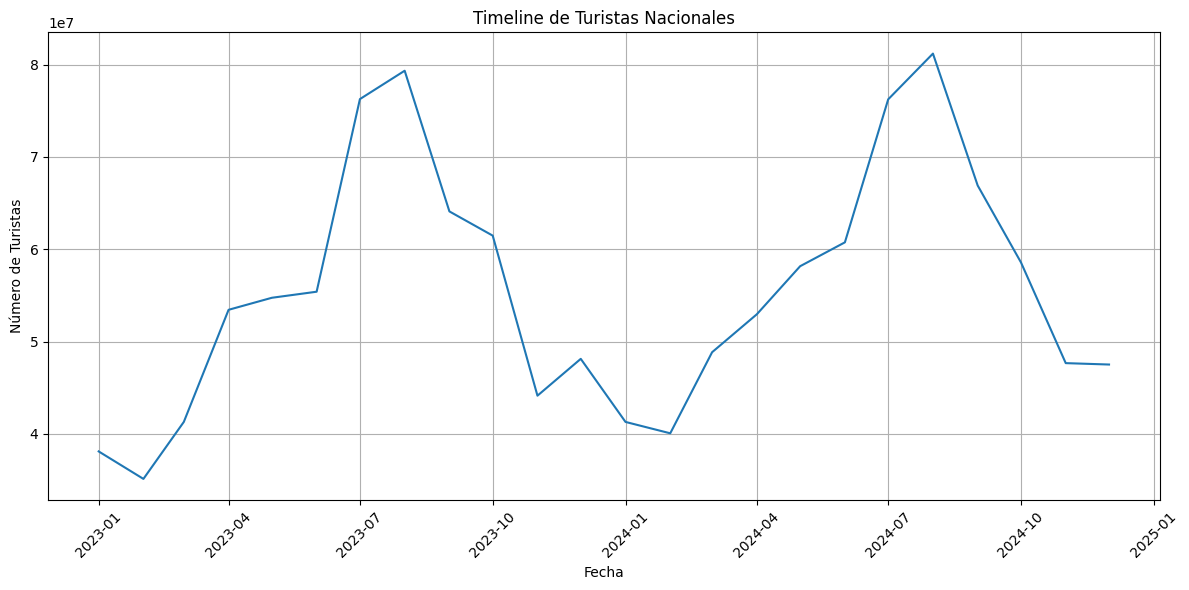

In [17]:
# Timeline de turistas nacionales por mes
plt.figure(figsize=(12,6))
sns.lineplot(data=df_totals, x='FECHA', y='TURISTAS_NACIONAL')
plt.title('Timeline de Turistas Nacionales')
plt.xlabel('Fecha')
plt.ylabel('Número de Turistas')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

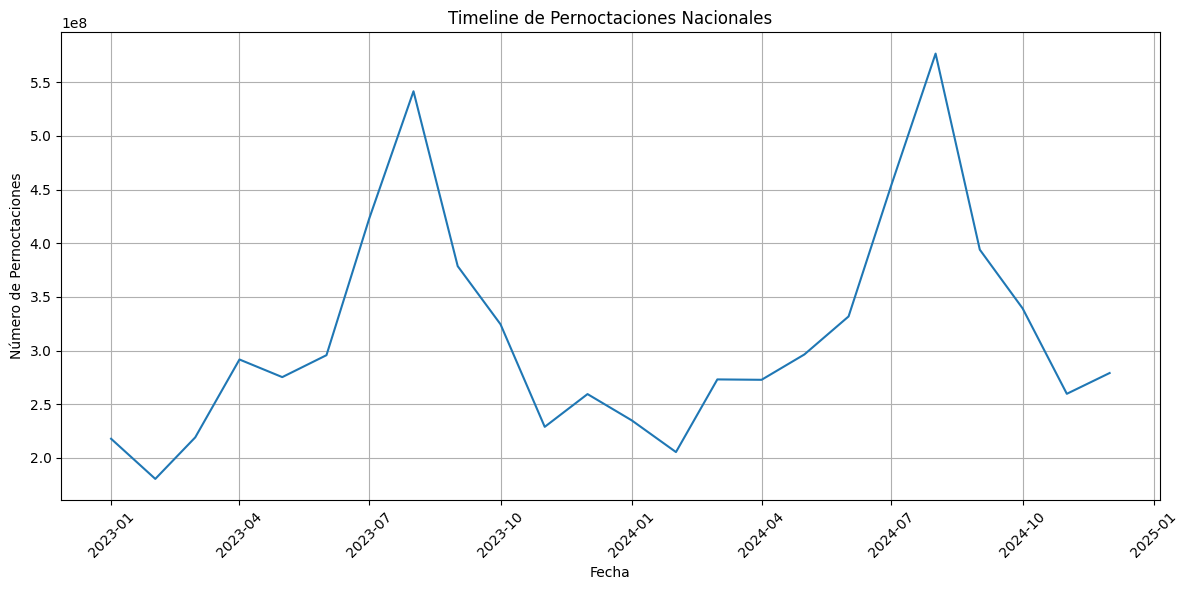

In [18]:
# Timeline de pernoctaciones de turistas nacionales por mes
plt.figure(figsize=(12,6))
sns.lineplot(data=df_totals, x='FECHA', y='PERNOCTACIONES_NACIONAL')
plt.title('Timeline de Pernoctaciones Nacionales')
plt.xlabel('Fecha')
plt.ylabel('Número de Pernoctaciones')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

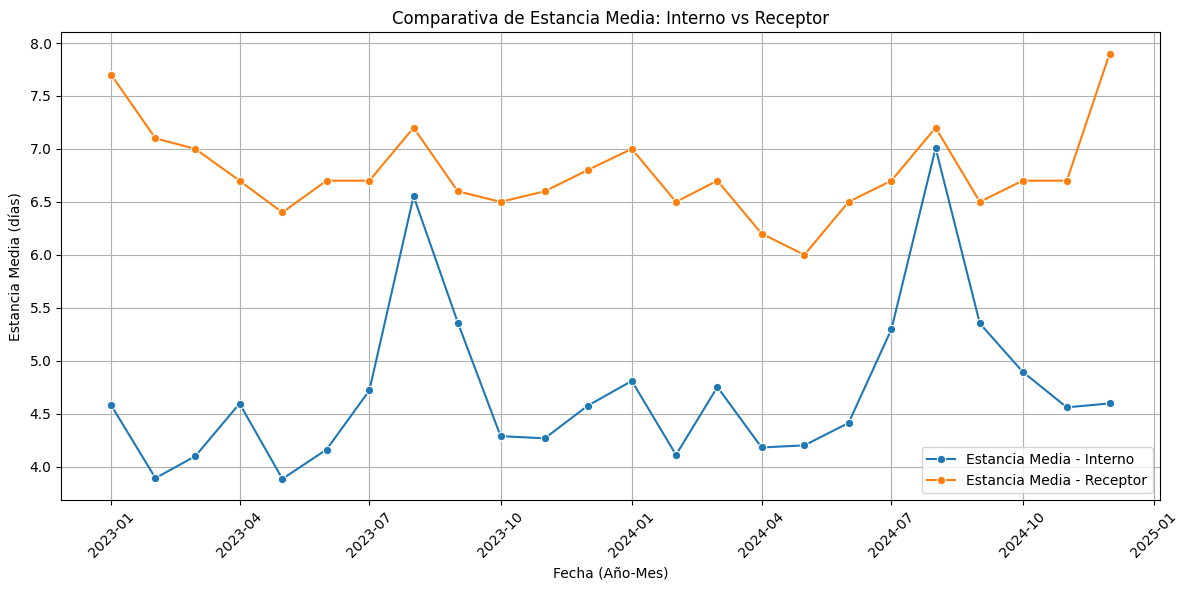

In [21]:
# Timeline comparativo de Estancia Media de turismo interno vs turismo receptor
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_totals, x='FECHA', y='ESTANCIA_MEDIA_INTERNO', label='Estancia Media - Interno', marker='o')
sns.lineplot(data=df_totals, x='FECHA', y='ESTANCIA_MEDIA_RECEPTOR', label='Estancia Media - Receptor', marker='o')
plt.title('Comparativa de Estancia Media: Interno vs Receptor')
plt.xlabel('Fecha (Año-Mes)')
plt.ylabel('Estancia Media (días)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

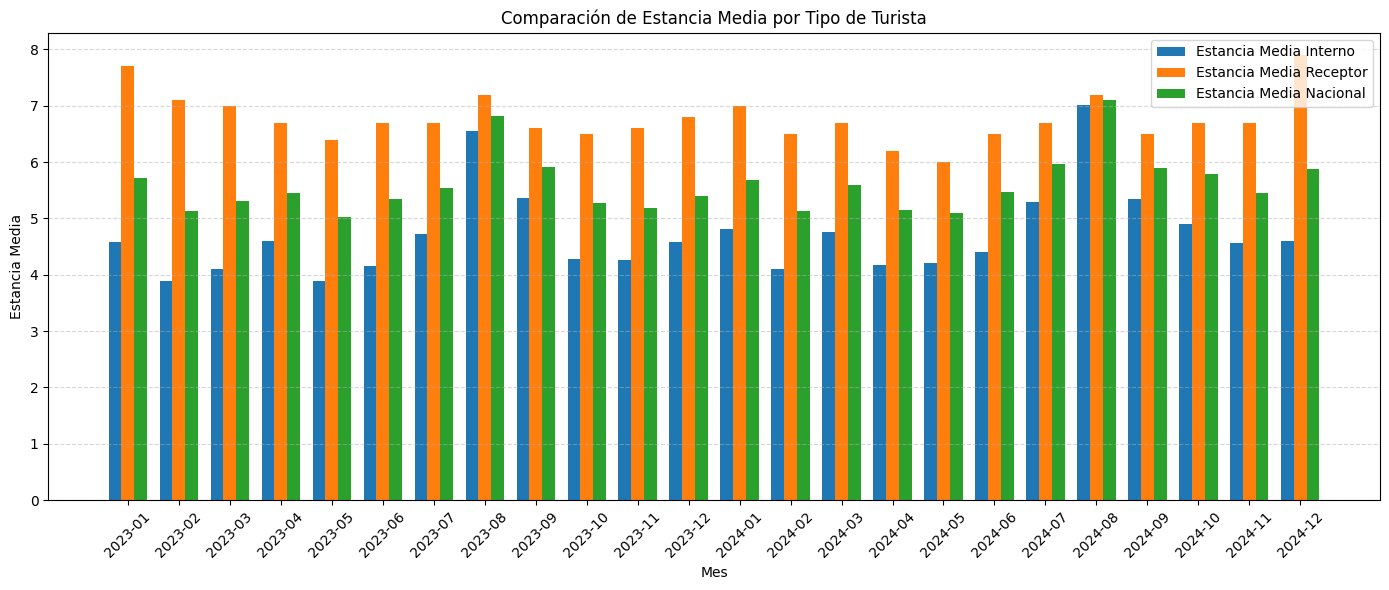

In [22]:
# Crear un gráfico de barras
plt.figure(figsize=(14, 6))

# Ancho y posición de las barras
bar_width = 0.25
x = range(len(df_totals))

# Asignar barras por cada variable
plt.bar([i - bar_width for i in x], df_totals['ESTANCIA_MEDIA_INTERNO'], 
        width=bar_width, label='Estancia Media Interno')
plt.bar(x, df_totals['ESTANCIA_MEDIA_RECEPTOR'], 
        width=bar_width, label='Estancia Media Receptor')
plt.bar([i + bar_width for i in x], df_totals['ESTANCIA_MEDIA_NACIONAL'], 
        width=bar_width, label='Estancia Media Nacional')

# Poner nombre al eje X
plt.xticks(x, df_totals['FECHA'].dt.to_period('M').astype(str), rotation=45)

# Labels and title
plt.xlabel('Mes')
plt.ylabel('Estancia Media')
plt.title('Comparación de Estancia Media por Tipo de Turista')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

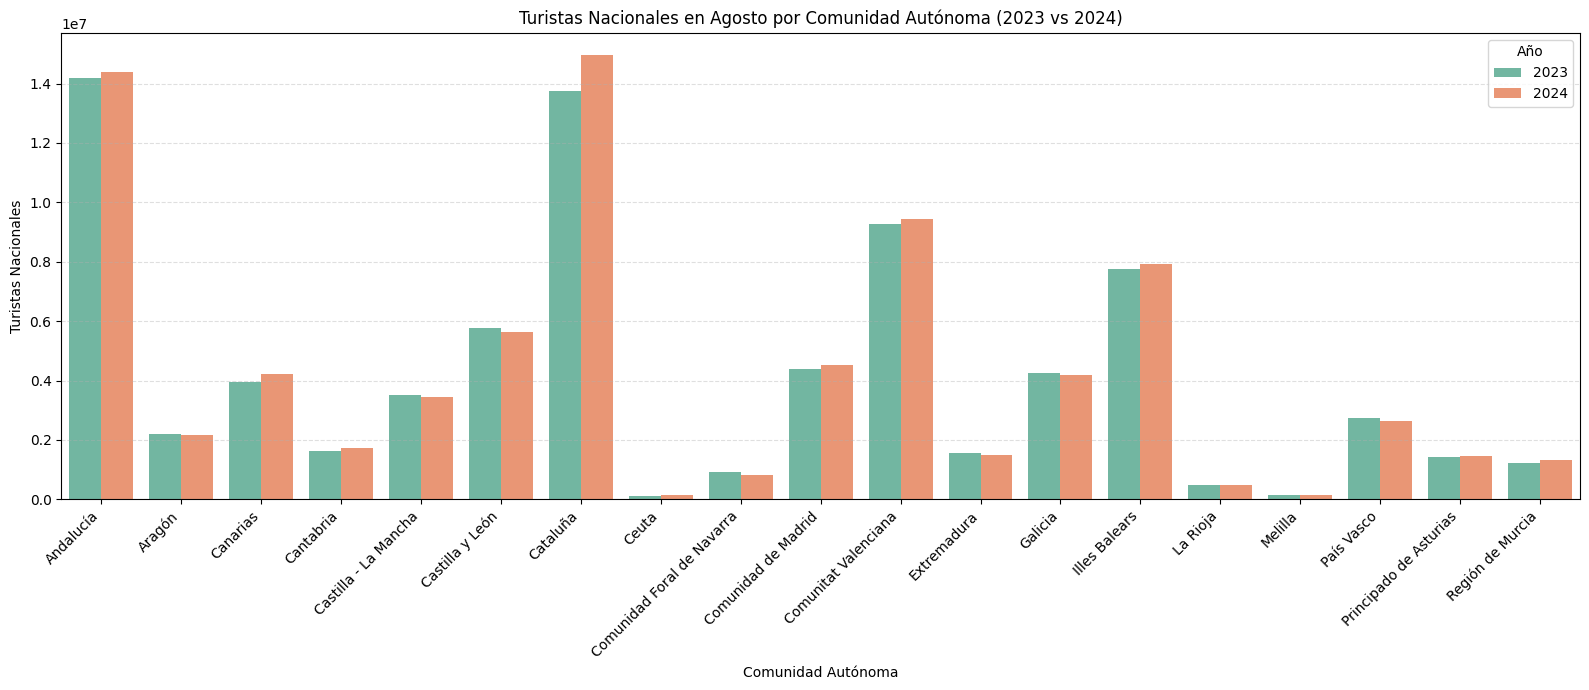

In [23]:
# Filtrar por el mes de agosto en ambos años excluyendo el total nacional
df_august = df[
    (df['FECHA'].dt.month == 8) &
    (df['CCAA_DESTINO'] != 'Total Nacional')
]


# Crear el gráfico
plt.figure(figsize=(16, 7))
sns.barplot(
    data=df_august,
    x='CCAA_DESTINO',
    y='TURISTAS_NACIONAL',
    hue=df_august['FECHA'].dt.year,
    palette='Set2'
)

# Labels and title
plt.xticks(rotation=45, ha='right')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Turistas Nacionales')
plt.title('Turistas Nacionales en Agosto por Comunidad Autónoma (2023 vs 2024)')
plt.legend(title='Año')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [24]:

# Filtrar datos en el año 2024 exluyendo el total nacional
df_2024 = df[
    (df['FECHA'].dt.year == 2024) &
    (df['CCAA_DESTINO'] != 'Total Nacional')
]

# Agregar los valores a cada región
df_map = df_2024.groupby("CCAA_DESTINO", as_index=False).agg({
    "TURISTAS_NACIONAL": "sum",
    "PERNOCTACIONES_NACIONAL": "sum",
    "ESTANCIA_MEDIA_NACIONAL": "mean"
})

# Crear el mapa
map_spain = folium.Map(location=[40.4168, -3.7038], zoom_start=6)

# Agregar los marcadores con popups para mostrar los datos
for region, coords in ccaa_coordinates.items():
    row = df_map[df_map["CCAA_DESTINO"] == region]
    if not row.empty:
        turistas = int(row["TURISTAS_NACIONAL"].values[0])
        pernoctaciones = int(row["PERNOCTACIONES_NACIONAL"].values[0])
        estancia = round(row["ESTANCIA_MEDIA_NACIONAL"].values[0], 2)
        
        popup_text = f"""
        <b>{region}</b><br>
        🧍‍♂️ Turistas Nacionales: {turistas:,}<br>
        🛏️ Pernoctaciones: {pernoctaciones:,}<br>
        📊 Estancia media: {estancia} días
        """
        
        folium.Marker(
            location=coords,
            popup=folium.Popup(popup_text, max_width=300),
            icon=folium.Icon(color="blue", icon="info-sign")
        ).add_to(map_spain)

# Guardar y verificar
map_spain.save("spain_ccaa_map_with_data.html")
print("✅ Map with data created! Open 'spain_ccaa_map_with_data.html' in your browser.")


✅ Map with data created! Open 'spain_ccaa_map_with_data.html' in your browser.


In [25]:
# Enseñar el mapa de Folium con los datos agregados
#map_spain

# Abrir el mapa de Folium en el browser con los datos agregados
webbrowser.open("spain_ccaa_map.html")

True

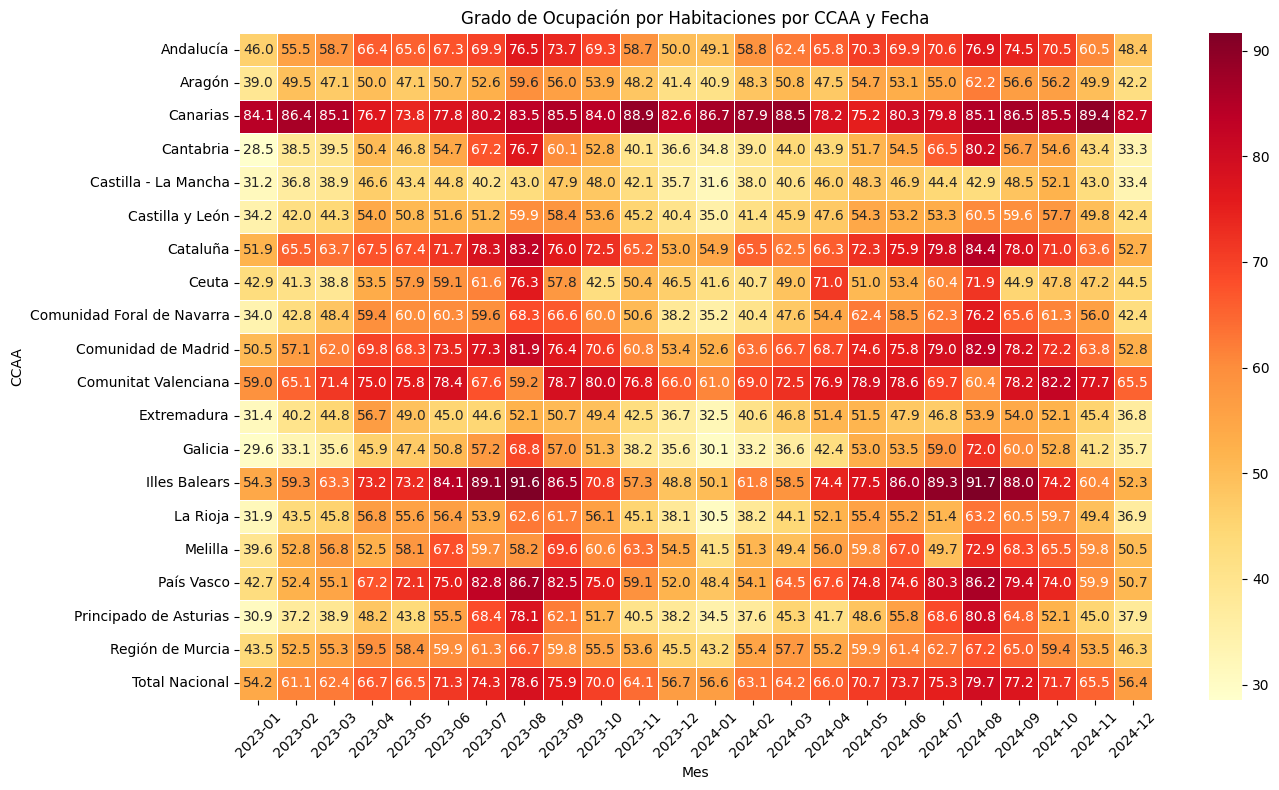

In [26]:
# Mapa de calor del grado de ocupación por habitaciones por CCAA y fecha

# Añadir FECHA_STR para mejor visualización
df['FECHA_STR'] = df['FECHA'].dt.strftime('%Y-%m')

# Crear una tabla pivot
heatmap_data = df.pivot_table(
    index='CCAA_DESTINO',
    columns='FECHA_STR',
    values='GRADO_OCUPA_POR_HABITACIONES',

)

# Crear el heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)

plt.title("Grado de Ocupación por Habitaciones por CCAA y Fecha")
plt.xlabel("Mes")
plt.ylabel("CCAA")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Filtrar el df
df_august_2024 = df[
    (df['FECHA'].dt.year == 2024) &
    (df['FECHA'].dt.month == 8) &
    (df['CCAA_DESTINO'] != 'Total Nacional')
]

# Definir la función para agregar colores a los marcadores
def get_color(value):
    if value > 85:
        return "lightgreen"
    elif 80 <= value <= 85:
        return "green"
    elif 70 <= value < 80:
        return "darkgreen"
    elif 60 <= value < 70:
        return "orange"
    else:
        return "red"

# Crear el mapa
map_august = folium.Map(location=[40.4168, -3.7038], zoom_start=6)

# Agregar los marcadores
for _, row in df_august_2024.iterrows():
    region = row["CCAA_DESTINO"]
    value = row["GRADO_OCUPA_POR_HABITACIONES"]
    coords = ccaa_coordinates.get(region)

    if coords and pd.notnull(value):
        folium.Marker(
            location=coords,
            popup=f"{region}: {value:.1f}%",
            icon=folium.Icon(color=get_color(value), icon="info-sign")
        ).add_to(map_august)

# Guardar el mapa y verificar
map_august.save("map_ocupacion.html")
print("✅ Map saved as 'map_ocupacion.html'")


✅ Map saved as 'map_ocupacion.html'


In [28]:
# Enseñar el mapa de Folium con los datos agregados
#map_august

# Abrir el mapa de Folium en el browser con los datos agregados
webbrowser.open("map_ocupacion.html")

True

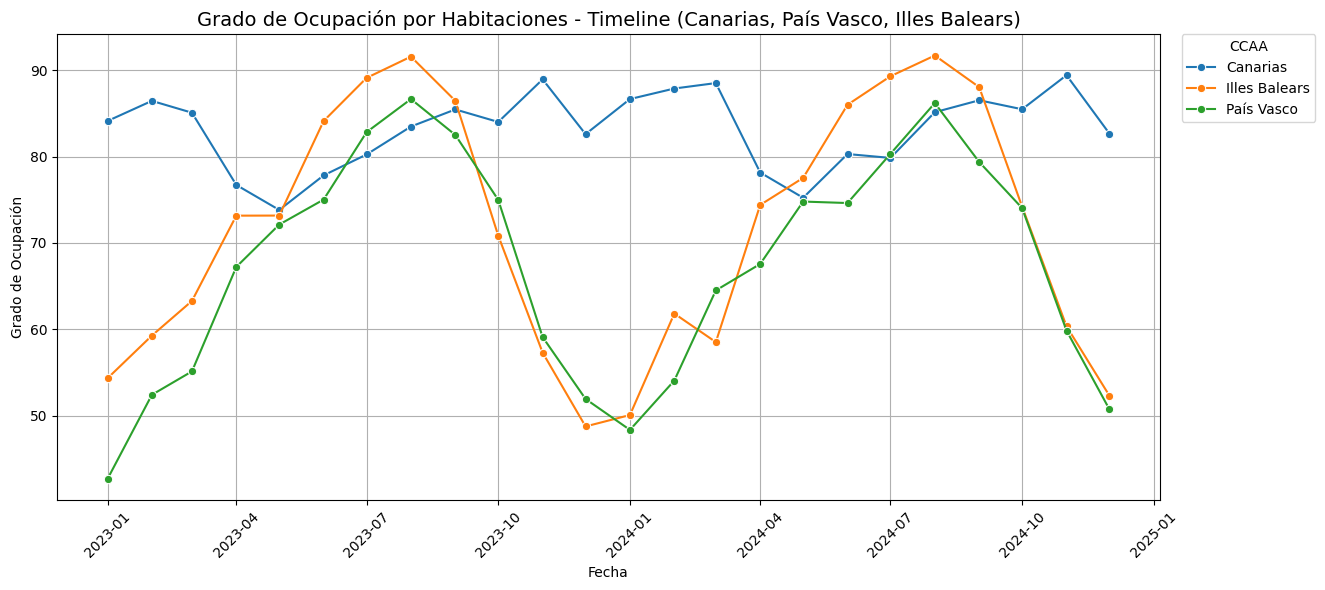

In [29]:
# Filtrar por las tres CCAA con mayor ocupación
ccaa_selected = ['Canarias', 'País Vasco', 'Illes Balears']
df_filtered = df[df['CCAA_DESTINO'].isin(ccaa_selected)]

# Crear el gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtered, x='FECHA', y='GRADO_OCUPA_POR_HABITACIONES', hue='CCAA_DESTINO', marker='o')

# Title and labels
plt.title('Grado de Ocupación por Habitaciones - Timeline (Canarias, País Vasco, Illes Balears)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Grado de Ocupación')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Move legend outside the plot
plt.legend(title='CCAA', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.show()

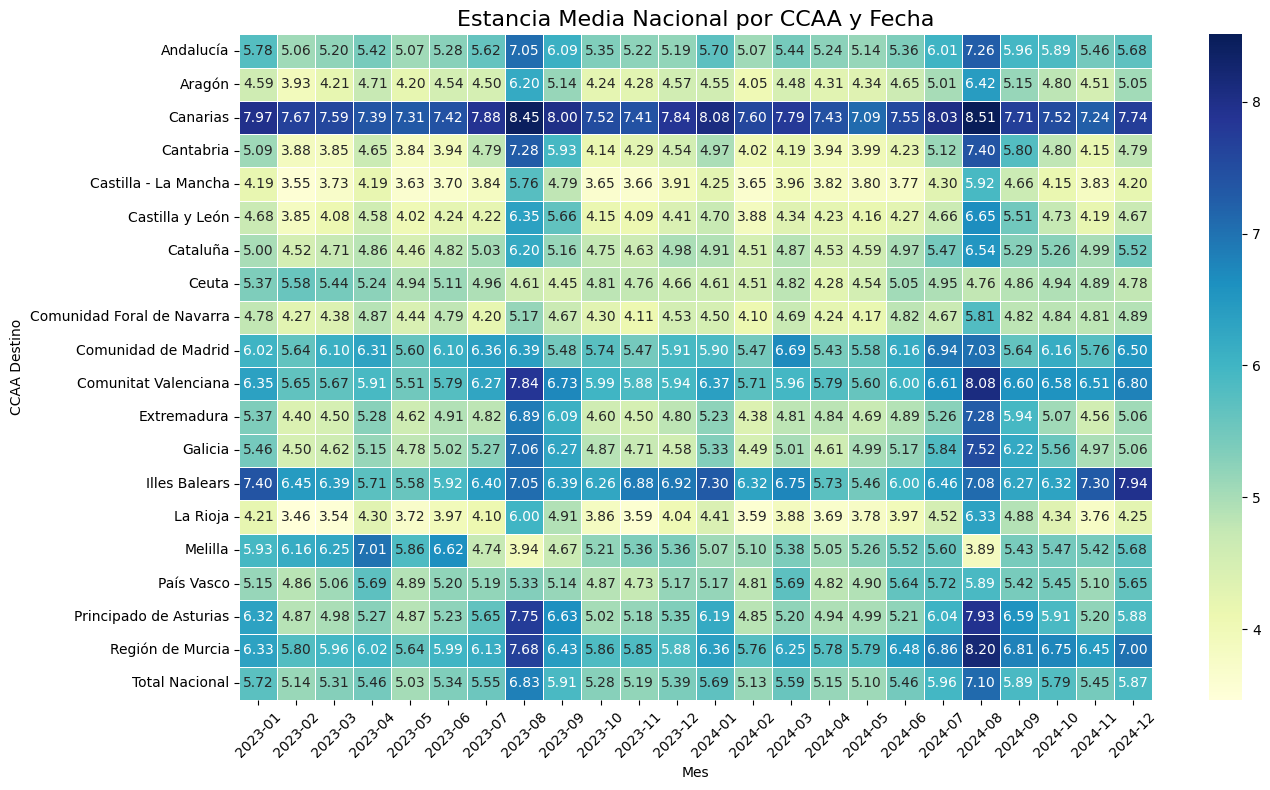

In [30]:
# Añadir FECHA_STR para mejorar la visualización
df['FECHA_MES'] = df['FECHA'].dt.to_period('M').astype(str)  # Format as 'YYYY-MM'

# Crear una tabla pivot
heatmap_data = df.pivot_table(
    index='CCAA_DESTINO',
    columns='FECHA_MES',
    values='ESTANCIA_MEDIA_NACIONAL'
)

# Crear el heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Estancia Media Nacional por CCAA y Fecha', fontsize=16)
plt.xlabel('Mes')
plt.ylabel('CCAA Destino')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:
# Definir funcion para elegir marcadores por colores
def get_color(value):
    if value > 8:
        return 'lightgreen'
    elif value > 7.5:
        return 'green'
    elif value > 7:
        return 'darkgreen'
    elif value > 6:
        return 'orange'
    else:
        return 'red'

# Crear mapa de Folium
map_estancia = folium.Map(location=[40.4168, -3.7038], zoom_start=6)

# Agregar marcadores para cada región
for _, row in df_august_2024.iterrows():
    region = row['CCAA_DESTINO']
    estancia = row['ESTANCIA_MEDIA_NACIONAL']
    coords = ccaa_coordinates.get(region)
    if coords:
        color = get_color(estancia)
        folium.Marker(
            location=coords,
            popup=f"{region}: {estancia:.2f} noches",
            icon=folium.Icon(color=color)
        ).add_to(map_estancia)

# Guardar y verificar
map_estancia.save("map_estancia_media_nacional.html")

print("✅ Map created and opened in your browser.")

✅ Map created and opened in your browser.


In [32]:
# Abrir el mapa de Folium con los datos agregados
#map_estancia

# Abrir el mapa de Folium en el browser con los datos agregados
webbrowser.open("map_estancia_media_nacional.html")

True

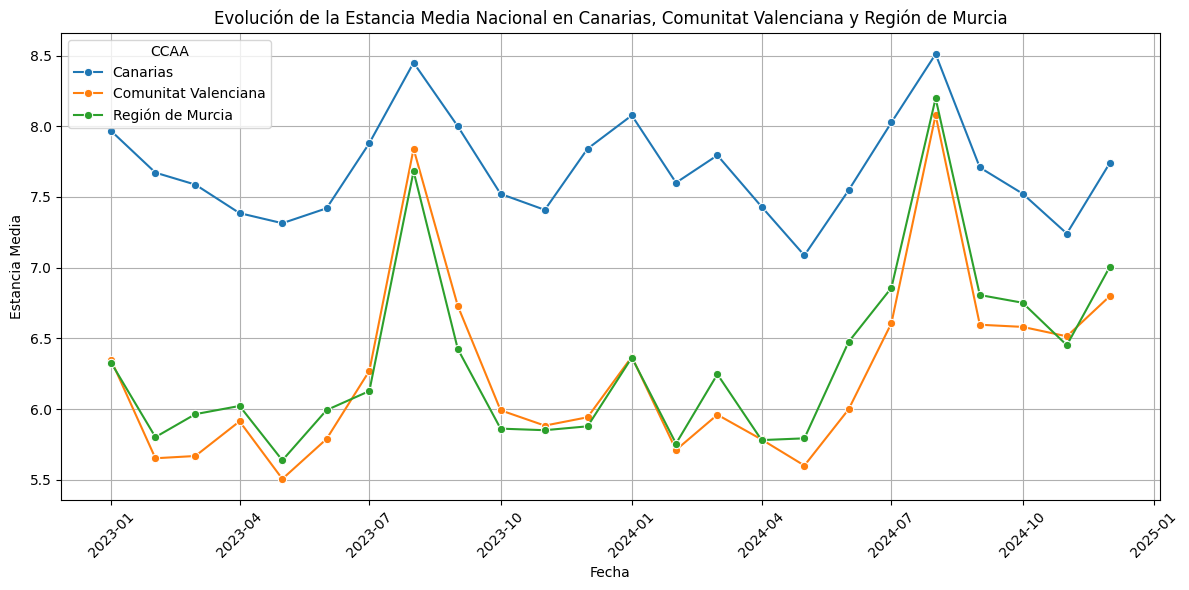

In [33]:
# Filtrar por las tres CCAA con mayor estancia media
ccaa_seleccionadas = ['Canarias', 'Comunitat Valenciana', 'Región de Murcia']
df_filtered = df[df['CCAA_DESTINO'].isin(ccaa_seleccionadas)]

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtered, x='FECHA', y='ESTANCIA_MEDIA_NACIONAL', hue='CCAA_DESTINO', marker='o')

# Formatting
plt.title("Evolución de la Estancia Media Nacional en Canarias, Comunitat Valenciana y Región de Murcia")
plt.xlabel("Fecha")
plt.ylabel("Estancia Media")
plt.xticks(rotation=45)
plt.legend(title='CCAA')
plt.grid(True)
plt.tight_layout()

plt.show()


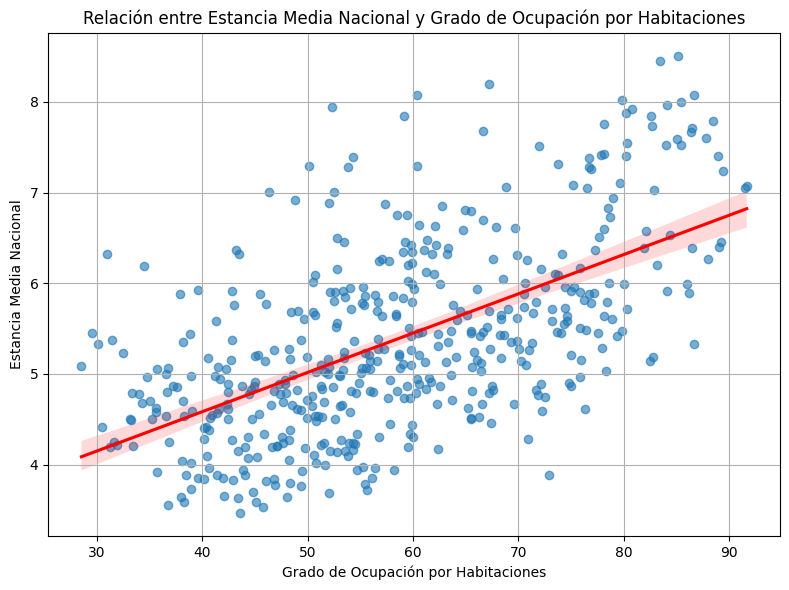

In [34]:
# Crear una gráfica de dispersión con regresión lineal para ver si existe correllación/
# entre el grado de ocupación en hoteles y la estancia media nacional
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x='GRADO_OCUPA_POR_HABITACIONES',
    y='ESTANCIA_MEDIA_NACIONAL',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title("Relación entre Estancia Media Nacional y Grado de Ocupación por Habitaciones")
plt.xlabel("Grado de Ocupación por Habitaciones")
plt.ylabel("Estancia Media Nacional")
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
# Calcular la correlación de Pearson
correlation = df[['GRADO_OCUPA_POR_HABITACIONES', 'ESTANCIA_MEDIA_NACIONAL']].corr(method='pearson')
print(correlation)


                              GRADO_OCUPA_POR_HABITACIONES  \
GRADO_OCUPA_POR_HABITACIONES                      1.000000   
ESTANCIA_MEDIA_NACIONAL                           0.593206   

                              ESTANCIA_MEDIA_NACIONAL  
GRADO_OCUPA_POR_HABITACIONES                 0.593206  
ESTANCIA_MEDIA_NACIONAL                      1.000000  


In [ ]:
# Visualizar las CCAA con mayor número de turistas nacionales
top_ccaa = (
    df[df['CCAA_DESTINO'] != 'Total Nacional']
    .groupby('CCAA_DESTINO')['TURISTAS_NACIONAL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_ccaa)

CCAA_DESTINO
Cataluña                234824331.0
Andalucía               223812891.0
Comunitat Valenciana    134297924.0
Comunidad de Madrid     131445684.0
Canarias                 99500035.0
Illes Balears            97834081.0
Castilla y León          88414196.0
Castilla - La Mancha     65351330.0
Galicia                  57696536.0
País Vasco               46772782.0
Name: TURISTAS_NACIONAL, dtype: float64
